# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training


### Answer
VAEs train not only on raw data but also use probabilities in latent space. Unlike standard autoencoders which use a fixed latent vector, VAEs point to probability distributions. VAEs also have smooth and continuous latent space unlike standard ones which have discontinuous.

VAE outputs two parameters $\mu$ and $\log(\sigma^2)$ where $\mu$ is believed to be the point around which latent space is distributed and $\log(\sigma^2)$ is the uncertainty with which the model predicts at a point. A higher $\sigma$ means higher uncertainty.

Reparametrization helps in separating randomness from learned parameters as the randomness is entirely in $\epsilon$ and gradients can smoothly flow through z enabling backpropagation.

In [17]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # TODO: define the encoder layers here
        # TODO: define the latent mean and log-variance layers here
        # TODO: define the decoder layers here

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc4 = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        # TODO: flatten the input and pass it through the encoder
        # TODO: return the latent mean and log-variance
        x = x.view(x.size(0), -1)
        enc = self.fc1(x)

        mu = self.fc_mu(enc)
        logvar = self.fc_logvar(enc)

        return mu, logvar
        raise NotImplementedError("Complete the encode method")

    def reparameterize(self, mu, logvar):
        # TODO: sample epsilon and apply the reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + (std * eps)

        return z
        raise NotImplementedError("Complete the reparameterize method")

    def decode(self, z):
        # TODO: map the latent vector back to the image space
        dec = self.fc3(z)
        recon = self.fc4(dec)

        return recon
        raise NotImplementedError("Complete the decode method")

    def forward(self, x):
        # TODO: connect encode -> reparameterize -> decode
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
        raise NotImplementedError("Complete the forward method")


# TODO: instantiate the model after completing the class
model = VAE().to(device)
print("VAE template ready for student implementation")


VAE template ready for student implementation


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

In [18]:
def vae_loss(recon_x, x, mu, logvar):
    x = x.view(-1, 28*28)
    # TODO: compute the reconstruction loss
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    # TODO: compute the KL divergence term
    kl_loss = - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # TODO: return the total VAE loss
    return recon_loss + kl_loss
    raise NotImplementedError("Complete the VAE loss function")


### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [19]:
# Hyperparameters
# TODO: choose appropriate batch size, number of epochs, and learning rate
batch_size = 128
epochs = 15
learning_rate = 1e-3

# Data transformation and loading
# TODO: add any preprocessing needed for MNIST
transform = transforms.ToTensor()

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# TODO: create the optimizer after the model has been defined
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
# TODO: complete the training loop
# Hint: move data to device, run the model, compute the loss, backpropagate, and update weights


for epoch in range(epochs):
    model.train()
    avg_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x)
        loss = vae_loss(recon_x, x, mu, logvar)

        loss.backward()
        optimizer.step()
        avg_loss += loss.item()

    avg_loss /= len(train_dataset)
    print(f"Epoch {epoch+1} | Average Loss : {avg_loss:.4f}")


Epoch 1 | Average Loss : 164.5631
Epoch 2 | Average Loss : 121.9444
Epoch 3 | Average Loss : 114.5258
Epoch 4 | Average Loss : 111.3947
Epoch 5 | Average Loss : 109.6700
Epoch 6 | Average Loss : 108.4942
Epoch 7 | Average Loss : 107.6357
Epoch 8 | Average Loss : 107.0268
Epoch 9 | Average Loss : 106.5349
Epoch 10 | Average Loss : 106.0568
Epoch 11 | Average Loss : 105.7234
Epoch 12 | Average Loss : 105.4424
Epoch 13 | Average Loss : 105.1345
Epoch 14 | Average Loss : 104.9038
Epoch 15 | Average Loss : 104.6995


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

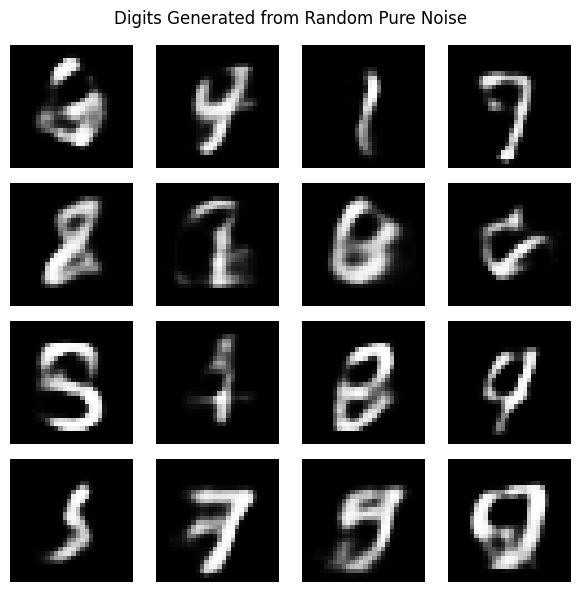

In [21]:
# TODO: write code to sample from the latent space using the trained decoder
# TODO: visualize the generated digits

with torch.no_grad():
    samples = torch.randn(16, 20).to(device)

    generated_pixels = model.decode(samples)
    generated_images = generated_pixels.view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')

fig.suptitle("Digits Generated from Random Pure Noise")
plt.tight_layout()
plt.show()



Some of the generated sample are quite easily identifiable while some appear to be a combination of two numbers. This tells that the VAE has succesfully organised a smooth and continuous latent space. The space is normalized and hence traversing through the space gives us distinct characteristics of one number to another. It didn't give images directly from the train dataset but rather gave numbers mixed with random noise to create unique variations. However, some digits are not really identifiable as they are morphed during the transition